In [1]:
import torch # install GPU-compatible
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, get_linear_schedule_with_warmup, AutoConfig
from datasets import Dataset
import evaluate
from tqdm import tqdm
from torch.nn import functional as F
import numpy as np
import pandas as pd
from torch.optim import AdamW
from sysml_utils import SysMLASTManager
from transformers import AutoModelForSeq2SeqLM, Trainer, TrainingArguments
from transformers import default_data_collator

model_name = "Salesforce/codet5-small"
cache_dir = "./models" 

import os
os.makedirs("models/trained", exist_ok=True)

In [2]:
tokenizer = AutoTokenizer.from_pretrained(model_name, cache_dir=cache_dir)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name, cache_dir=cache_dir)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

def count_tokens(text: str) -> int:
    tokens = tokenizer.encode(text, add_special_tokens=False)
    return len(tokens)

In [3]:
import matplotlib.pyplot as plt

def plot_token_lengths(dataset, column_name):

    # Handle both Hugging Face Dataset and pandas DataFrame
    if hasattr(dataset, "to_pandas"):
        texts = dataset[column_name]  # works for Hugging Face Datasets
    else:
        texts = dataset[column_name]  # works for pandas DataFrame

    # Convert all entries to string (safe)
    texts = [str(t) for t in texts]

    # Tokenize and count
    token_counts = [len(tokenizer.encode(t, add_special_tokens=False)) for t in texts]

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(range(len(token_counts)), token_counts)
    plt.xlabel("Example index")
    plt.ylabel("Token count")
    plt.title(f"Token counts per example")
    plt.grid(True)
    plt.show()

    return token_counts


In [4]:
basic_df = pd.read_json("dataset/synthetic_dataset_basic_expanded_final.jsonl", lines=True)
domain_df = pd.read_json("dataset/synthetic_dataset_domain_aware_full.jsonl", lines=True) 

merged_df = pd.concat([basic_df, domain_df], ignore_index=True)
dataset = Dataset.from_pandas(merged_df)

Token indices sequence length is longer than the specified maximum sequence length for this model (937 > 512). Running this sequence through the model will result in indexing errors


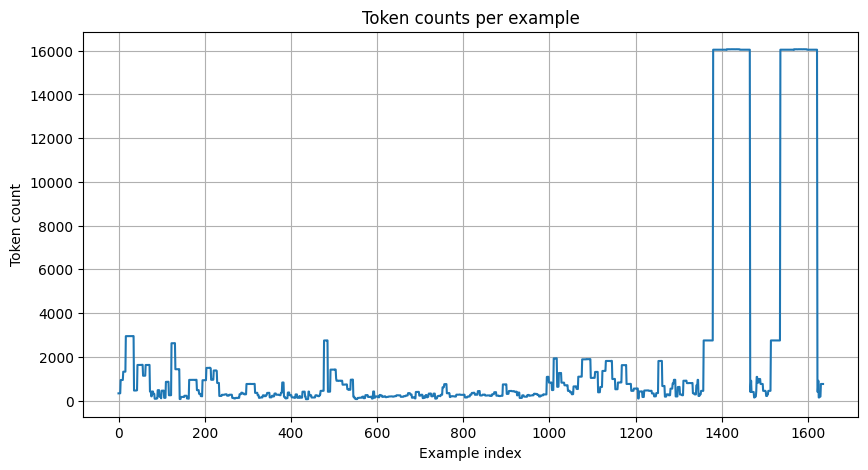

In [5]:
token_counts = plot_token_lengths(dataset, "bad_code")

In [10]:
text = dataset[200]["error_message"]
formatted = text.replace("ERROR:", "\nERROR:")
import pprint
print(count_tokens(text))  
print(formatted)


922

ERROR:Couldn't resolve reference to Element 'Publish'. (265.sysml line : 23 column : 29) 
ERROR:Couldn't resolve reference to Type 'Subscribe'. (265.sysml line : 40 column : 19) 
ERROR:Couldn't resolve reference to Type 'Publish'. (265.sysml line : 46 column : 19) 
ERROR:Couldn't resolve reference to Element 'topic'. (265.sysml line : 47 column : 13) 
ERROR:Couldn't resolve reference to Element 'Deliver'. (265.sysml line : 48 column : 18) 
ERROR:Couldn't resolve reference to Element 'publication'. (265.sysml line : 48 column : 30) 
ERROR:Couldn't resolve reference to Element 'Subscribe'. (265.sysml line : 62 column : 31) 
ERROR:Couldn't resolve reference to Type 'Deliver'. (265.sysml line : 63 column : 33) 
ERROR:Couldn't resolve reference to Type 'PubSubSequence'. (265.sysml line : 69 column : 23) 
ERROR:Couldn't resolve reference to Feature 'producer'. (265.sysml line : 70 column : 12) 
ERROR:Couldn't resolve reference to Feature 'server'. (265.sysml line : 71 column : 12) 
ERRO

In [11]:
text = dataset[200]["bad_code"]
print(count_tokens(text))  
print(text)

928
package ServerSequenceOutsideRealization_2 {
	private import ScalarValues::String;
	private import ServerSequenceModelOutside::*;
	private import Configuration::*;
	
	package Configuration {
		
		port def PublicationPort;
		
		port def SubscriptionPort;
		
		part producer_2[1] {
			attribute someTopic : String;
			private item somePublication;
			/* Requiring FIFO sort (as opposed to just default) to make arrival/leave ordering
			 * in ServerSequenceModelOutside.sysml equivalent to accept/send new ordering in
			 * ServerSquenceRealization-2.sysml. */
			:>> incomingTransferSort = Occurrences::earlierFirstIncomingTransferSort;
			
			port publicationPort : PublicationPort;
			
			perform action producerBehavior {
				action publish send new Publish(someTopic, somePublication) via publicationPort;
			}
		}
		
		interface producer_2.publicationPort to server_2.publicationPort;
		
		part server_2[1] {
			port publicationPort : PublicationPort;
			port subscriptionPort : SubscriptionP

In [37]:
def preprocess_data(batch, keep_original=True):
    input_texts = [
        f"Fix the following SysML code.\n### Faulty Code:\n{wc}\n### Error:\n{err}"
        for wc, err in zip(batch["bad_code"], batch["error_message"])
    ]
    target_texts = [
        f"Here is the correct code:\n{code}"
        for code in batch["good_code"]
    ]

    if keep_original:
        batch["input_text"] = input_texts
        batch["target_text"] = target_texts
        return batch
    else:
        return {"input_text": input_texts, "target_text": target_texts}


def group_split(dataset, test_size=0.1, val_size=0.1, seed=42):
    base_ids = list(set(dataset["source_id"]))
    rng = np.random.default_rng(seed)
    shuffled = rng.permutation(base_ids)

    n = len(shuffled)
    n_test = int(test_size * n)
    n_val = int(val_size * n)

    test_groups = set(shuffled[:n_test])
    val_groups  = set(shuffled[n_test:n_test+n_val])

    def label_row(example):
        if example["source_id"] in test_groups:
            return {"split": "test"}
        elif example["source_id"] in val_groups:
            return {"split": "val"}
        else:
            return {"split": "train"}

    dataset = dataset.map(label_row)

    train_ds = dataset.filter(lambda x: x["split"] == "train").remove_columns("split")
    val_ds   = dataset.filter(lambda x: x["split"] == "val").remove_columns("split")
    test_ds  = dataset.filter(lambda x: x["split"] == "test").remove_columns("split")

    return train_ds, val_ds, test_ds

dataset = dataset.map(preprocess_data, batched=True)
train_ds, val_ds, test_ds = group_split(dataset)
print(f"Datatset Sizes: \nTraining: {len(train_ds)}, Validation: {len(val_ds)}, Test: {len(test_ds)}")

Map:   0%|          | 0/1636 [00:00<?, ? examples/s]

Map:   0%|          | 0/1636 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1636 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1636 [00:00<?, ? examples/s]

Filter:   0%|          | 0/1636 [00:00<?, ? examples/s]

Datatset Sizes: 
Training: 1388, Validation: 108, Test: 140


In [38]:
def tokenize_function(batch, max_length=256):

    model_inputs = tokenizer(
        text=batch["input_text"],
        text_target=batch["target_text"],
        max_length=max_length,
        padding="max_length",
        truncation=True,
    )

    return model_inputs

train_tokenized = train_ds.map(tokenize_function, batched=True, remove_columns=train_ds.column_names)
val_tokenized = val_ds.map(tokenize_function, batched=True, remove_columns=val_ds.column_names)
test_tokenized = test_ds.map(tokenize_function, batched=True, remove_columns=test_ds.column_names)

train_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/1388 [00:00<?, ? examples/s]

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

Map:   0%|          | 0/140 [00:00<?, ? examples/s]

In [39]:
def tokenize_function(batch, max_length=256):

    model_inputs = tokenizer(
        text=batch["input_text"],
        text_target=batch["target_text"],
    )

    return model_inputs

dataset_tok = dataset.map(tokenize_function, batched=True, remove_columns=train_ds.column_names)

Map:   0%|          | 0/1636 [00:00<?, ? examples/s]

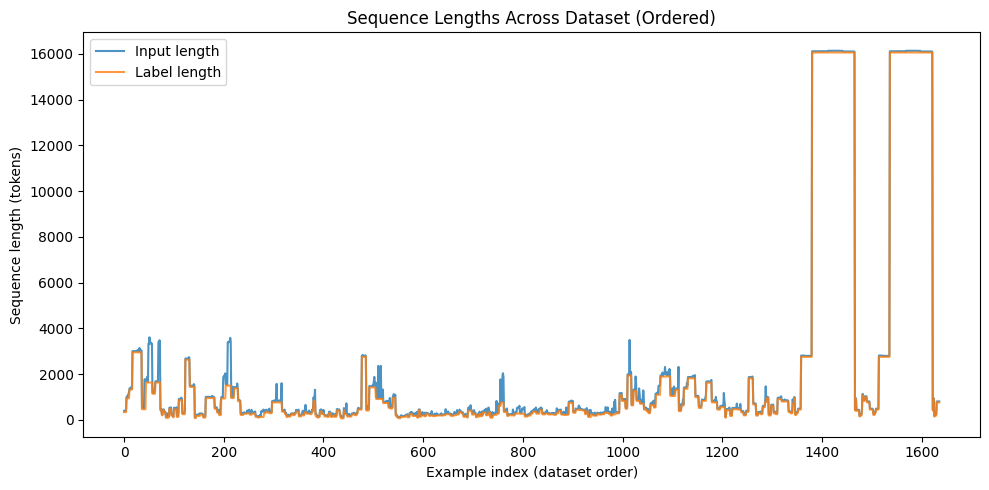

Inputs: mean=2387.9, max=16132, min=103
Labels: mean=2285.7, max=16055, min=69


In [40]:
import matplotlib.pyplot as plt

def plot_seq_lengths_over_examples(dataset, num_samples=None):
    """Plot sequence lengths vs example index (dataset order)."""
    if num_samples:
        dataset = dataset.select(range(min(num_samples, len(dataset)))) if hasattr(dataset, "select") else dataset[:num_samples]

    input_lengths = [len(example["input_ids"]) for example in dataset]
    label_lengths = [len(example["labels"]) for example in dataset]

    plt.figure(figsize=(10, 5))
    plt.plot(input_lengths, label="Input length", alpha=0.8)
    plt.plot(label_lengths, label="Label length", alpha=0.8)
    plt.xlabel("Example index (dataset order)")
    plt.ylabel("Sequence length (tokens)")
    plt.title("Sequence Lengths Across Dataset (Ordered)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Inputs: mean={sum(input_lengths)/len(input_lengths):.1f}, max={max(input_lengths)}, min={min(input_lengths)}")
    print(f"Labels: mean={sum(label_lengths)/len(label_lengths):.1f}, max={max(label_lengths)}, min={min(label_lengths)}")

# Example usage:
plot_seq_lengths_over_examples(dataset_tok)



In [ ]:
def compute_accuracy(outputs, labels):
    preds = outputs.logits.argmax(-1)
    mask = labels != -100

    correct = (preds == labels) & mask
    accuracy = correct.sum().item() / mask.sum().item()
    return accuracy

In [ ]:
train_loader = DataLoader(train_tokenized, batch_size=4, shuffle=True, collate_fn=default_data_collator)
val_loader   = DataLoader(val_tokenized, batch_size=4, collate_fn=default_data_collator)

num_epochs = 10
optimizer = AdamW(model.parameters(), lr=5e-5)
num_training_steps = len(train_loader) * num_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)

In [ ]:
train_losses = []
val_losses = []
best_val_loss = float('inf') 
patience = 2
patience_counter = 0

for epoch in range(num_epochs):

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1} [Training]")
    model.train()
    train_loss = 0.0
    
    for batch in train_loop:
        for k,v in batch.items():
            batch[k] = v.to(device)
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    val_loop = tqdm(val_loader, desc=f"Epoch {epoch+1} [Validation]")
    model.eval()
    val_loss = 0.0
    total_acc = 0.0
    
    with torch.no_grad():
        for batch in val_loop:
            for k,v in batch.items():
                batch[k] = v.to(device)
            outputs = model(**batch)
            val_loss += outputs.loss.item()
            labels = batch["labels"]
            acc = compute_accuracy(outputs, labels)
            total_acc += acc

    avg_val_loss = val_loss / len(val_loader)
    avg_acc = total_acc / len(val_loader)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_val_loss: 
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "models/trained/best_model.pt")
        print(f"Train loss: {avg_train_loss:.4f}, Validation loss: {avg_val_loss:.4f}, Best: {best_val_loss:.4f}, Accuracy: {avg_acc:.4f}")
    else:
        patience_counter += 1
        print(f"Train loss: {avg_train_loss:.4f}, Validation loss: {avg_val_loss:.4f}, Best: {best_val_loss:.4f}, Accuracy: {avg_acc:.4f}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

print(f"Best model saved (val loss = {best_val_loss:.4f})")

In [ ]:
model.load_state_dict(torch.load("models/trained/best_model.pt"))
model.to(device)
model.eval()
import torch, gc
gc.collect()
torch.cuda.empty_cache()
test_loader = DataLoader(test_tokenized, batch_size=1, collate_fn=default_data_collator)

In [ ]:
generated_texts = []
reference_texts = []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Generating"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # Generate output
        generated_ids = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            num_beams=4,          # or 1 for greedy
            max_new_tokens=256,     # generate up to 256 new tokens
            early_stopping=False,   # ignore early EOS
        )

        # Decode both
        preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
        labels = tokenizer.batch_decode(batch["labels"], skip_special_tokens=True)

        generated_texts.extend(preds)
        reference_texts.extend(labels)


In [ ]:
# compute BLEU
bleu = evaluate.load("sacrebleu")  # optional
results = bleu.compute(predictions=generated_texts,
                       references=[[r] for r in reference_texts])

print(f"BLEU score: {results['score']:.2f}")
exact_matches = sum(p.strip() == r.strip() for p, r in zip(generated_texts, reference_texts))
exact_match_acc = exact_matches / len(reference_texts)
print(f"Exact-match accuracy: {exact_match_acc:.3f}")

In [ ]:
print(tokenizer.eos_token, tokenizer.eos_token_id)
print(model.config.eos_token_id)


In [ ]:
for i in range(5):
    print(f"Reference: {reference_texts[i]}")
    print(f"Generated: {generated_texts[i]}")
    print("---")


In [ ]:
from transformers.trainer_utils import EvalPrediction

def compute_metrics(eval_pred: EvalPrediction):
    preds = eval_pred.predictions
    labels = eval_pred.label_ids
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    print("Trynna compute metrics")

    pred_texts = tokenizer.batch_decode(preds, skip_special_tokens=True)
    label_texts = tokenizer.batch_decode(labels, skip_special_tokens=True)

    acc = np.mean([p.strip() == l.strip() for p, l in zip(pred_texts, label_texts)])
    return {"accuracy": acc}

In [ ]:
# old code, uses trainer
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments, EarlyStoppingCallback

training_args = Seq2SeqTrainingArguments(
    output_dir="./checkpoints",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=10,
    fp16=True,  # use mixed precision, lowers memeory usage

    report_to="none",
    do_eval=True,
    predict_with_generate=False,
    logging_strategy="epoch",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]

)
#eval_accumulation_steps=1,     # prevents OOM
trainer.train()

In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()


from transformers import AutoModelForSeq2SeqLM

model_path = "./checkpoints"
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)
model.eval()
model.to("cuda")


In [ ]:
test_tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Then:
test_results = trainer.predict(test_tokenized)
print(test_results.metrics)

In [ ]:
import evaluate, numpy as np
metric = evaluate.load("accuracy")

from tqdm import tqdm

def evaluate_model(model, tokenizer, dataset, max_length=128):
    preds, refs = [], []
    for batch in tqdm(dataset, desc="Evaluating"):
        inputs = tokenizer(
            batch["input_text"],
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length
        ).to("cuda")

        with torch.no_grad():
            outputs = model.generate(**inputs, max_length=max_length)

        pred_str = tokenizer.batch_decode(outputs, skip_special_tokens=True)
        ref_str = batch["target_text"]

        preds.extend(pred_str)
        refs.extend(ref_str)

    acc = np.mean([p.strip() == r.strip() for p, r in zip(preds, refs)])
    return acc

# Run
test_acc = evaluate_model(model, tokenizer, test_dataset)
print(f"Final test accuracy: {test_acc:.3f}")
